# Introduction

This notebook calculates the signal-to-noise ratio achieved with MICHELANGELO with the L band, useful for calculation of unresolved targets.

The calculation assumes that MICHELANGELO performs similar to CRIRES+ in terms of efficiency and of adaptive optics. The key differences are that:
- MICHELANGELO has a broader simultaneous wavelength coverage;
- CRIRES+ has a few very broad orders that are "sliced" by the detectors (hence: low efficiency in some settings towards the border of the orders). MICHELANGELO will have much lower losses due to the narrower orders.
- MICHELANGELO has about hald the resolving power compared to CRIRES+

We therefore run the CRIRES+ ETC, join results from the different CRIRES+ detectors and orders, change the blaze throughput efficiency to a more appropriate one, and resample to a wavelength solution that represents MICHELANGELO. Note that the CRIRES+ settings L3262 and L3302 sample the peak of the blaze function of CRIRES+, and MICHELANGELO has similar expected performance in the wavelengths covered by these modes, but better performance elsewhere.

In [50]:
import numpy as np
import json
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from scipy.ndimage import uniform_filter1d
import subprocess
from IPython.display import display, JSON

## Running the CRIRES+ ETC.

In the current example, we are observing a system with the following parameters:
- Star: $T_{eff} = 7500 \mathrm{K}$, blackbody, K = 6.41;
- airmass 1.2, 0.5 moon illumination, 2.5 precipitable water vapor;
- DIT = 10s, NDIT = 1

These are passed as arguments to the CRIRES+ ETC. More options can be implemented, but deemed less useful for now. 

**Important** The keyword "run_etc" decides whether the ETC will be run. This operation is time consuming, I thus suggest to run it only once a new setting is selected. If "run_etc = False", the code will try to read pre-existing files produced by the ETC. If "run_etc = True" the code will **overwrite** pre-exiting ETC output, therefore make sure that the "dict_modify_json" dictionary matches the file name. No check is performed by this code.

In [51]:
etc_run_name = 'nominal_M_dit10s'
# etc_run_name = 'nominal_M_dit150s'
run_etc = True

# Keys to modify in the json.
dict_modify_json = {
    'Kmag':6.41,
    'T_eff':7500.,
    'airmass':1.2,
    'moon_fli':0.5,
    'pwv':2.5,
    'DIT':10,
    'NDIT':1
}

# MICHELANGELO parameters: don't change unless you know why you are doing it!
resolving_power = 50000.
spectral_sampling = 2.7
lambda_min = 43000
lambda_max = 55000

# lambda_i+1 = lambda_i *(1 + 1/R)
# lambda_max = lamdba_min * (1 + 1/R)^N, then take log and isolate N.
n_pixels = int(np.log(lambda_max/lambda_min)/np.log(1+1/resolving_power)*spectral_sampling)
approximate_MICHELANGELO_wavelength_solution = np.logspace(np.log10(lambda_min), np.log10(lambda_max), num=n_pixels)

The following functions run the ETC, if requested.

In [52]:
# Load the JSON input file
def load_json(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# Save the modified JSON input file
def save_json(data, filename, output_dir = 'etc_input_files/'):
    with open(output_dir+filename, 'w') as file:
        json.dump(data, file, indent=4)

# Modify input parameters interactively
def modify_parameters(input_data, dict_modify_json):
    for key, value in dict_modify_json.items():
        if key == 'Kmag':
            input_data['target']['brightness']['mag'] = value
        if key == 'T_eff':
            input_data['target']['sed']['temperature'] = value
        if key == 'airmass':
            input_data['sky']['airmass'] = value
        if key == 'moon_fli':
            input_data['sky']['moon_fli'] = value
        if key == 'pwv':
            input_data['sky']['pwv'] = value
        if key == 'DIT':
            input_data['timesnr']['DET1.DIT'] = value
        if key == 'NDIT':
            input_data['timesnr']['DET1.NDIT'] = value
    return input_data

# Run etc_cli.py with the modified JSON input
def run_etc_cli(etc_script, json_file, output_file, instrument_name="crires2", input_dir = 'etc_input_files/', output_dir = 'output_CRIRES_ETC_command_line/'):
    
    command = ["python3", etc_script, instrument_name, input_dir+json_file, "-o", output_dir+output_file+'.json']
    result = subprocess.run(command, capture_output=True, text=True)
    print("Run {}. Parameters: {}".format(json_file, dict_modify_json))
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)

if run_etc:
    # Paths to files
    template_json_file = "etc_input_template_Mband.json" # Do not modify
    this_run_json_file = "{}.json".format(etc_run_name)
    etc_script = "etc_cli.py"

    # # Load, modify, save, and run
    # input_data = load_json(template_json_file)
    # modified_input_data = modify_parameters(input_data, dict_modify_json)
    # save_json(modified_input_data, this_run_json_file)
    # run_etc_cli(etc_script, this_run_json_file, output_file=etc_run_name)

    # All L-band modes
    # Load, modify, save, and run
    input_data = load_json(template_json_file)
    for mode in ['M4519', 'M4504', 'M4461', 'M4416', 'M4368', 'M4318', 'M4266', 'M4211', 'M4187']:
        modified_input_data = modify_parameters(input_data, dict_modify_json)
        input_data['instrument']['settingkey'] = mode
        save_json(modified_input_data, this_run_json_file)
        run_etc_cli(etc_script, this_run_json_file, output_file=etc_run_name+'_' + mode)

Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7500.0, 'airmass': 1.2, 'moon_fli': 0.5, 'pwv': 2.5, 'DIT': 10, 'NDIT': 1}
STDOUT: 
STDERR: 
Run nominal_M_dit40s.json. Parameters: {'Kmag': 6.41, 'T_eff': 7

The following block reads the CRIRES+ ETC output and saves all important quantities in arrays.

In [53]:
wavelength_array = []
obstarget_array = []
sky_array = []

stellar_noise_array = []
sky_noise_array = []
ron_noise_array = []
dark_noise_array = []
total_noise_array = []

throughput_atmosphere_array = []
throughput_blaze_array = []
throughput_detector_array = []
throughput_enslittedenergy_array = []
throughput_instrument_array = []
throughput_telescope_array = []
throughput_totalinclsky_array = []

snr_array = []
maxpixeltarget_array = []
maxpixelsky_array = []
maxpixeltotal_array = []

for mode, color in zip(['M4519', 'M4504', 'M4461', 'M4416', 'M4368', 'M4318', 'M4266', 'M4211', 'M4187'], ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']):
    etc_results_file = 'output_CRIRES_ETC_command_line/{}'.format(etc_run_name+'_'+mode)
    with open('{}.json'.format(etc_results_file)) as f:
        etc_output = json.load(f)['data']
    
    n_observations = 1
    
    wavelength_array_mode = []
    obstarget_array_mode = []
    sky_array_mode = []
    
    stellar_noise_array_mode = []
    sky_noise_array_mode = []
    ron_noise_array_mode = []
    dark_noise_array_mode = []
    total_noise_array_mode = []

    throughput_atmosphere_array_mode = []
    throughput_blaze_array_mode = []
    throughput_detector_array_mode = []
    throughput_enslittedenergy_array_mode = []
    throughput_instrument_array_mode = []
    throughput_telescope_array_mode = []
    throughput_totalinclsky_array_mode = []
    
    snr_array_mode = []
    maxpixeltotal_array_mode = []
    maxpixeltarget_array_mode = []
    maxpixelsky_array_mode = []

    for order in etc_output['orders']:
        order_name = order['order']
        for detector in order['detectors']:
            detector_name = detector['name']
    
            wavelength = np.array(detector['wavelength'])*1.e10 # Angstroms
            wavelength_array_mode.append(wavelength)
    
            obstarget = np.array(detector['noise_components']['target'])
            obstarget_array_mode.append(obstarget)
    
            sky = np.array(detector['noise_components']['sky'])
            sky_array_mode.append(sky)
            
            # All the noise components are the variances. You can compare with the online ETC (what goes in the square root for the noise are the variances).
            #
            # So in practice these are:
            # noise_components.noise_terms.target_term = noise_components.obstarget
            # noise_components.noise_terms.sky_term = sky
            # noise_components.noise_terms.ron_term = noise_components.noise_info.ron2 * noise_components.noise_info.nspat * noise_components.noise_info.nspec
            # noise_components.noise_terms.dark_term = noise_components.noise_info.nspat * noise_components.noise_info.dit * noise_components.noise_info.dark
            #
            
            stellar_noise_term = np.array(detector['noise_components']['noise_terms']['target_term'])
            sky_noise_term = np.array(detector['noise_components']['noise_terms']['sky_term'])
            ron_noise_term = np.array(detector['noise_components']['noise_terms']['ron_term'])
            dark_noise_term = np.array(detector['noise_components']['noise_terms']['dark_term'])
            
            stellar_noise_array_mode.append(stellar_noise_term)
            sky_noise_array_mode.append(sky_noise_term)
            ron_noise_array_mode.append(ron_noise_term)
            dark_noise_array_mode.append(dark_noise_term)
    
            total_noise = np.sqrt(stellar_noise_term + sky_noise_term + ron_noise_term + dark_noise_term)/np.sqrt(n_observations)
            total_noise_array_mode.append(total_noise)

            throughput_atmosphere = np.array(detector['plots']['throughput']['atmosphere'])
            throughput_blaze = np.array(detector['plots']['throughput']['blaze'])
            throughput_detector = np.array(detector['plots']['throughput']['detector'])
            throughput_enslittedenergy = np.array(detector['plots']['throughput']['enslittedenergy'])
            throughput_instrument = np.array(detector['plots']['throughput']['instrument'])
            throughput_telescope = np.array(detector['plots']['throughput']['telescope'])
            throughput_totalinclsky = np.array(detector['plots']['throughput']['totalinclsky'])
            
            throughput_atmosphere_array_mode.append(throughput_atmosphere)
            throughput_blaze_array_mode.append(throughput_blaze)
            throughput_detector_array_mode.append(throughput_detector)
            throughput_enslittedenergy_array_mode.append(throughput_enslittedenergy)
            throughput_instrument_array_mode.append(throughput_instrument)
            throughput_telescope_array_mode.append(throughput_telescope)
            throughput_totalinclsky_array_mode.append(throughput_totalinclsky)

            snr_array_mode.append(np.array(detector['plots']['snr']['snr']))
            maxpixeltotal_array_mode.append(np.array(detector['plots']['maxsignals']['maxpixeltotal']))
            maxpixeltarget_array_mode.append(np.array(detector['plots']['maxsignals']['maxpixeltarget']))
            maxpixelsky_array_mode.append(np.array(detector['plots']['maxsignals']['maxpixelsky']))


    wavelength_array_mode = np.array(wavelength_array_mode)
    obstarget_array_mode = np.array(obstarget_array_mode)
    sky_array_mode = np.array(sky_array_mode)
    stellar_noise_array_mode = np.array(stellar_noise_array_mode)
    sky_noise_array_mode = np.array(sky_noise_array_mode)
    ron_noise_array_mode = np.array(ron_noise_array_mode)
    dark_noise_array_mode = np.array(dark_noise_array_mode)

    throughput_atmosphere_array_mode = np.array(throughput_atmosphere_array_mode)
    throughput_blaze_array_mode = np.array(throughput_blaze_array_mode)
    throughput_detector_array_mode = np.array(throughput_detector_array_mode)
    throughput_enslittedenergy_array_mode = np.array(throughput_enslittedenergy_array_mode)
    throughput_instrument_array_mode = np.array(throughput_instrument_array_mode)
    throughput_telescope_array_mode = np.array(throughput_telescope_array_mode)
    throughput_totalinclsky_array_mode = np.array(throughput_totalinclsky_array_mode)
    
    snr_array_mode = np.array(snr_array_mode)

    wavelength_array.append(wavelength_array_mode)
    obstarget_array.append(obstarget_array_mode)
    sky_array.append(sky_array_mode)

    stellar_noise_array.append(stellar_noise_array_mode)
    sky_noise_array.append(sky_noise_array_mode)
    ron_noise_array.append(ron_noise_array_mode)
    dark_noise_array.append(dark_noise_array_mode)
    total_noise_array.append(total_noise_array_mode)

    throughput_atmosphere_array.append(throughput_atmosphere_array_mode)
    throughput_blaze_array.append(throughput_blaze_array_mode)
    throughput_detector_array.append(throughput_detector_array_mode)
    throughput_enslittedenergy_array.append(throughput_enslittedenergy_array_mode)
    throughput_instrument_array.append(throughput_instrument_array_mode)
    throughput_telescope_array.append(throughput_telescope_array_mode)
    throughput_totalinclsky_array.append(throughput_totalinclsky_array_mode)

    snr_array.append(snr_array_mode)
    maxpixeltotal_array.append(maxpixeltotal_array_mode)
    maxpixeltarget_array.append(maxpixeltarget_array_mode)
    maxpixelsky_array.append(maxpixelsky_array_mode)

wavelength_array = np.array(wavelength_array)
pixel_size_array = np.diff(wavelength_array, axis=2)
obstarget_array = np.array(obstarget_array)
sky_array = np.array(sky_array)

stellar_noise_array = np.array(stellar_noise_array)
sky_noise_array = np.array(sky_noise_array)
ron_noise_array = np.array(ron_noise_array)
dark_noise_array = np.array(dark_noise_array)
total_noise_array = np.array(total_noise_array)

throughput_atmosphere_array = np.array(throughput_atmosphere_array)
throughput_blaze_array = np.array(throughput_blaze_array)
throughput_detector_array = np.array(throughput_detector_array)
throughput_enslittedenergy_array = np.array(throughput_enslittedenergy_array)
throughput_instrument_array = np.array(throughput_instrument_array)
throughput_telescope_array = np.array(throughput_telescope_array)
throughput_totalinclsky_array = np.array(throughput_totalinclsky_array)

snr_array = np.array(snr_array)
maxpixeltotal_array = np.array(maxpixeltotal_array)
maxpixeltarget_array = np.array(maxpixeltarget_array)
maxpixelsky_array = np.array(maxpixelsky_array)


The following block computes the MICHELANGELO performance based on CRIRES+'s.

All throughputs are multiplicative, therefore we multiply the blaze efficiency point by point by the ratio of the MICHELANGELO and CRIRES+ blaze efficiency. The MICHELANGELO blaze efficiency is taken as constantly equal to 0.6, which represents the efficiency in the central part of an order. This is because MICHELANGELO covers the wavelength range more densely with orders compared to CRIRES+.

Since the angular dimension on sky of an individual pixel is similar between CRIRES+ and MICHELANGELO, the only difference to the number of counts in each pixel is the resolving power. We take this into account on a point-by-point basis, noting that the number of counts per wavelength is proportional to the spectral energy density, hence must be conserved.

In [54]:
print(wavelength_array)

[[[36407.96846753 36408.06761232 36408.16675458 ... 36605.41213575
   36605.50607782 36605.60001734]
  [36619.36569906 36619.45926027 36619.55281892 ... 36805.32946389
   36805.41776278 36805.50605908]
  [36818.66260156 36818.7505089  36818.83841366 ... 36993.00632824
   36993.08891718 36993.17150351]
  ...
  [52957.04504369 52957.18925429 52957.33346121 ... 53244.23583382
   53244.37247683 53244.50911612]
  [53264.53192591 53264.66801494 53264.80410025 ... 53535.02467475
   53535.1531095  53535.28154048]
  [53554.41832954 53554.54619477 53554.67405624 ... 53808.00920471
   53808.12933408 53808.24945965]]

 [[36287.17436437 36287.27520776 36287.37604864 ... 36488.11125539
   36488.20691505 36488.30257217]
  [36502.32055293 36502.41583308 36502.51111067 ... 36691.81800303
   36691.90803875 36691.99807188]
  [36705.41407761 36705.50372307 36705.59336595 ... 36883.3295838
   36883.41392765 36883.49826889]
  ...
  [52781.34452999 52781.49121129 52781.63788893 ... 53073.61637147
   53073.75

In [55]:
sorting_mask_crop = np.argsort(np.ravel(wavelength_array[:,:,:-1])) # We crop one element because we are approximating the real pixel size with the difference between two consecutive wavelengths of central pixels, resulting in loss of one element.

sorted_wavelength_array = np.ravel(wavelength_array[:,:,:-1])[sorting_mask_crop]

MICHELANGELO_blaze_efficiency = 0.6*np.ones_like(throughput_blaze_array)
MICHELANGELO_over_CRIRES_efficiency = MICHELANGELO_blaze_efficiency/throughput_blaze_array

 # Taking into account that the pixel size of CRIRES+ is not uniform. This quantity is proportional to the spectral flux/energy density.
MICHELANGELO_target_counts_per_unit_wavelength_appo = np.ravel(obstarget_array[:,:,:-1]*MICHELANGELO_over_CRIRES_efficiency[:,:,:-1]/pixel_size_array)[sorting_mask_crop]
MICHELANGELO_sky_counts_per_unit_wavelength_appo = np.ravel(sky_array[:,:,:-1]*MICHELANGELO_over_CRIRES_efficiency[:,:,:-1]/pixel_size_array)[sorting_mask_crop]

# Since this is now proportioal to a flux/energy density, it can be interpolated to the desired wavelength grid
MICHELANGELO_pixel_size = np.diff(approximate_MICHELANGELO_wavelength_solution)
MICHELANGELO_obstarget = np.interp(approximate_MICHELANGELO_wavelength_solution[:-1], sorted_wavelength_array, MICHELANGELO_target_counts_per_unit_wavelength_appo)*MICHELANGELO_pixel_size
MICHELANGELO_sky = np.interp(approximate_MICHELANGELO_wavelength_solution[:-1], sorted_wavelength_array, MICHELANGELO_sky_counts_per_unit_wavelength_appo)*MICHELANGELO_pixel_size

For noise, we calculate the equivalent CRIRES+ ETC terms, obtained as poissonian noise for sky and target, while dark and RON are constant and the same. Indeed:
- $\sigma^2_{RON} = N_{pix}\cdot RON^2$
- $\sigma^2_{dark} = N_{pix}\cdot DIT \cdot dark$

$N_{pix} = N_{spat}\cdot N_{spec}$ and we assume the same extraction aperture (hence same number of spatial pixels) while we do not bin hence $N_{spec}=1$ as it is in he CRIRES+ ETC

In [56]:
MICHELANGELO_target_noise_term = MICHELANGELO_obstarget
MICHELANGELO_sky_noise_term = MICHELANGELO_sky
MICHELANGELO_ron_noise_term = np.ones_like(MICHELANGELO_obstarget)*ron_noise_array[0,0] # Constant! So use first element
MICHELANGELO_dark_noise_term = np.ones_like(MICHELANGELO_obstarget)*dark_noise_array[0,0] # Constant! So use first element

Text(0.5, 1.0, 'DIT = 10 s')

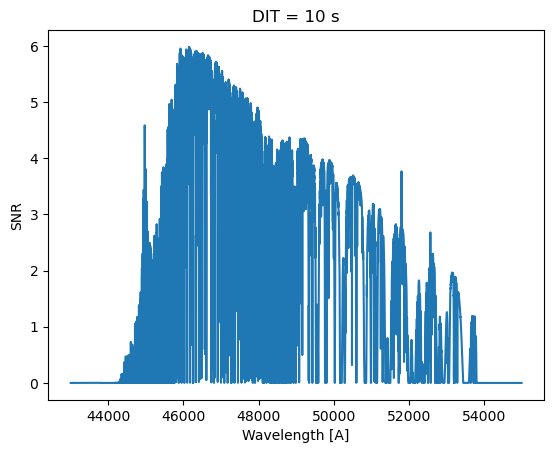

In [59]:
MICHELANGELO_SNR = np.sqrt(detector['noise_components']['noise_info']['ndit'])*MICHELANGELO_obstarget/np.sqrt(MICHELANGELO_target_noise_term + MICHELANGELO_sky_noise_term + MICHELANGELO_ron_noise_term + MICHELANGELO_dark_noise_term)

plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICHELANGELO_SNR)
plt.ylabel('SNR')
plt.xlabel('Wavelength [A]')
plt.title('DIT = {} s'.format(detector['noise_components']['noise_info']['dit']))

## Saturation

Since the sky is bright in the L band, it might cause saturation. The following block approximately checks for saturation, assuming the same saturation as CRIRES+'s. This check is performed on the individual exposure. The saturation needs to be checked against the maximum count in the single pixel, rather than on the aperture integrated flux.

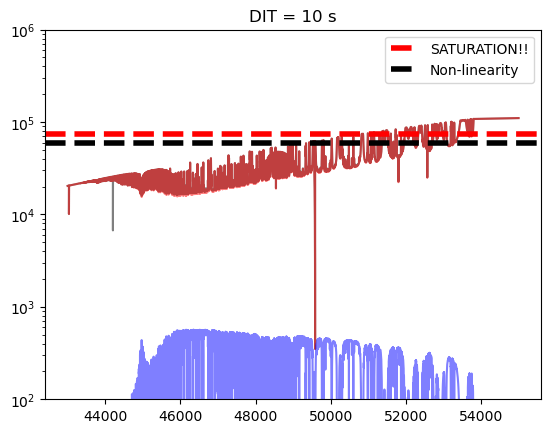

In [66]:
non_linearity_limit = 60000 # electron counts
saturation_limit = 74000 # electron counts

MICHELANGELO_maxpixeltotal_per_unit_wavelength_appo = np.ravel(maxpixeltotal_array[:,:,:-1]*MICHELANGELO_over_CRIRES_efficiency[:,:,:-1]/pixel_size_array)[sorting_mask_crop]
MICHELANGELO_maxpixeltarget_per_unit_wavelength_appo = np.ravel(maxpixeltarget_array[:,:,:-1]*MICHELANGELO_over_CRIRES_efficiency[:,:,:-1]/pixel_size_array)[sorting_mask_crop]
MICHELANGELO_maxpixelsky_per_unit_wavelength_appo = np.ravel(maxpixelsky_array[:,:,:-1]*MICHELANGELO_over_CRIRES_efficiency[:,:,:-1]/pixel_size_array)[sorting_mask_crop]


MICEHLANGELO_maxpixeltotal = np.interp(approximate_MICHELANGELO_wavelength_solution[:-1], sorted_wavelength_array, MICHELANGELO_maxpixeltotal_per_unit_wavelength_appo)*MICHELANGELO_pixel_size
MICEHLANGELO_maxpixeltarget = np.interp(approximate_MICHELANGELO_wavelength_solution[:-1], sorted_wavelength_array, MICHELANGELO_maxpixeltarget_per_unit_wavelength_appo)*MICHELANGELO_pixel_size
MICEHLANGELO_maxpixelsky = np.interp(approximate_MICHELANGELO_wavelength_solution[:-1], sorted_wavelength_array, MICHELANGELO_maxpixelsky_per_unit_wavelength_appo)*MICHELANGELO_pixel_size

plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICEHLANGELO_maxpixeltotal, 'k', alpha=0.5)
plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICEHLANGELO_maxpixelsky, 'r', alpha=0.5)
plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICEHLANGELO_maxpixeltarget, 'b', alpha=0.5)

plt.axhline(saturation_limit, linewidth = 4, linestyle='--', color='red', label='SATURATION!!')
plt.axhline(non_linearity_limit, linewidth = 4, linestyle='--', color='black', label='Non-linearity')
plt.title('DIT = {} s'.format(detector['noise_components']['noise_info']['dit']))

plt.yscale('log')
plt.ylim(ymin=100, ymax = 1.e6)

plt.legend()

In [ ]:
detector['plots']['maxsignals'].keys()

dict_keys(['maxpixelsky', 'maxpixeltarget', 'maxpixeltotal'])

## Noise analysis

We can compare the individual contributions of noise to verify which is the dominant contribution

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/var/folders/l0/bhnq9lh54rlg3dq_k5cgdb7c0000gn/T/ipykernel_4491/3724513224.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma^2$')


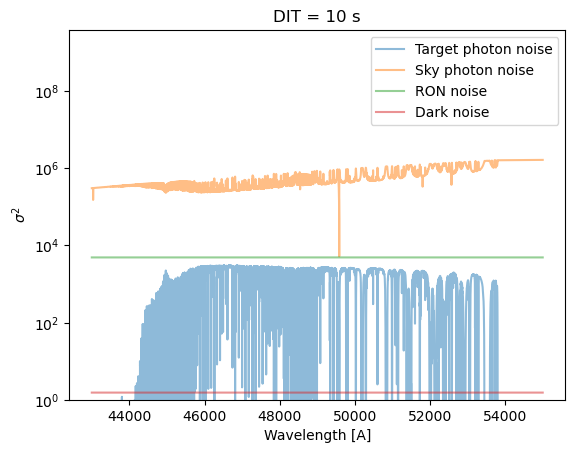

In [64]:
plt.figure()

plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICHELANGELO_target_noise_term, label='Target photon noise', alpha=0.5)
plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICHELANGELO_sky_noise_term, label='Sky photon noise', alpha=0.5)
plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICHELANGELO_ron_noise_term, label='RON noise', alpha=0.5)
plt.plot(approximate_MICHELANGELO_wavelength_solution[:-1], MICHELANGELO_dark_noise_term, label='Dark noise', alpha=0.5)

plt.yscale("log")
plt.ylabel('$\sigma^2$')
plt.xlabel('Wavelength [A]')
plt.ylim(ymin=1)
plt.title('DIT = {} s'.format(detector['noise_components']['noise_info']['dit']))

plt.legend()